# FLAML AutoML: полный train

Здесь модель учится на всех признаках из исходного `train.csv` кроме `target`, с тем же честным стратифицированным holdout `80/20` (`random_state=42`). 

> Используйте Python 3.12 в окружении проекта. На более новых версиях Python у части AutoML/бустинговых библиотек могут быть несовместимости.

In [1]:
from pathlib import Path

import gc
import os
import random
import pickle
import warnings

for warn in [FutureWarning, UserWarning]:
    warnings.filterwarnings("ignore", category=warn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flaml.automl.automl import AutoML

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

## Настройка путей и логирования


In [3]:
DEFAULT_PROJECT_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton")

if DEFAULT_PROJECT_DIR.exists():
    PROJECT_DIR = DEFAULT_PROJECT_DIR
else:
    PROJECT_DIR = Path.cwd().resolve()
    if PROJECT_DIR.name == "modeling":
        PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
LOGS_DIR = PROJECT_DIR / "logs" / "flaml_automl_full_fields_log"
MODELS_DIR = PROJECT_DIR / "models" / "flaml_automl_full_fields_models"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)


def resolve_csv_path(file_name):
    candidates = [
        DATA_DIR / file_name,
        PROJECT_DIR / "raw_data" / file_name,
        PROJECT_DIR / "processed_data" / file_name,
        PROJECT_DIR / file_name,
    ]
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Не нашел {file_name}. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


TRAIN_PATH = resolve_csv_path("train.csv")
TEST_PATH = resolve_csv_path("test.csv")

print("PROJECT_DIR:", PROJECT_DIR)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("LOGS_DIR:", LOGS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("SUBMISSIONS_DIR:", SUBMISSIONS_DIR)

PROJECT_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton
TRAIN_PATH: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/train.csv
TEST_PATH: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/test.csv
LOGS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/flaml_automl_full_fields_log
MODELS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_full_fields_models
SUBMISSIONS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions


## Загрузка полного train/test

По умолчанию не удаляем даже квазиконстантные признаки: эксперимент именно про «все поля».  
Если захочется повторить EDA-фильтр `>99% одного значения`, можно включить `DROP_QUASI_CONSTANT_FEATURES = True`.

In [4]:
TARGET_COL = "target"
INDEX_COL = 0

DROP_QUASI_CONSTANT_FEATURES = False
QUASI_CONSTANT_THRESHOLD = 0.99
FORCE_FLOAT32 = True


def memory_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2


def encode_non_numeric_inplace(train_features, test_features):
    non_numeric_cols = train_features.select_dtypes(exclude=[np.number]).columns.tolist()
    if not non_numeric_cols:
        print("non-numeric columns: 0")
        return train_features, test_features

    print(f"non-numeric columns: {len(non_numeric_cols)} -> factorize train+test consistently")
    for col in non_numeric_cols:
        joined = pd.concat([train_features[col], test_features[col]], axis=0, ignore_index=True)
        codes, _ = pd.factorize(joined, sort=True)
        train_features[col] = codes[: len(train_features)].astype(np.int32)
        test_features[col] = codes[len(train_features) :].astype(np.int32)

    return train_features, test_features


def optimize_numeric_dtypes_inplace(df):
    if not FORCE_FLOAT32:
        return df

    float64_cols = df.select_dtypes(include=["float64"]).columns
    if len(float64_cols):
        df[float64_cols] = df[float64_cols].astype(np.float32)

    int64_cols = df.select_dtypes(include=["int64"]).columns
    for col in int64_cols:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    return df


print("read train/test...")
train_df = pd.read_csv(TRAIN_PATH, index_col=INDEX_COL)
test_df = pd.read_csv(TEST_PATH, index_col=INDEX_COL)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"В train.csv нет target-колонки {TARGET_COL!r}")

feature_cols = [col for col in train_df.columns if col != TARGET_COL]
missing_in_test = sorted(set(feature_cols) - set(test_df.columns))
if missing_in_test:
    raise ValueError(f"В test.csv нет признаков из train.csv: {missing_in_test[:20]}")

extra_in_test = sorted(set(test_df.columns) - set(feature_cols))
if extra_in_test:
    print(f"В test.csv есть лишние колонки, игнорируем: {extra_in_test[:20]}")

X_full = train_df[feature_cols].copy()
y_full = train_df[TARGET_COL].values.ravel()
X_test = test_df[feature_cols].copy()

if DROP_QUASI_CONSTANT_FEATURES:
    print("Поиск квазиконстантных признаков...")
    most_freq_share = X_full.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
    low_variance_cols = most_freq_share[most_freq_share > QUASI_CONSTANT_THRESHOLD].index.tolist()
    X_full = X_full.drop(columns=low_variance_cols)
    X_test = X_test.drop(columns=low_variance_cols, errors="ignore")
    print(f"Удалено квазиконстантных признаков: {len(low_variance_cols)}")
else:
    print("Квазиконстантные признаки не удаляем: режим всех полей.")

X_full, X_test = encode_non_numeric_inplace(X_full, X_test)

print(f"before downcast: X_full={memory_mb(X_full):.1f} MB, X_test={memory_mb(X_test):.1f} MB")
X_full = optimize_numeric_dtypes_inplace(X_full)
X_test = optimize_numeric_dtypes_inplace(X_test)
print(f"after downcast:  X_full={memory_mb(X_full):.1f} MB, X_test={memory_mb(X_test):.1f} MB")

print("train shape:", X_full.shape)
print("test shape:", X_test.shape)
print("target distribution:")
print(pd.Series(y_full).value_counts(normalize=True).sort_index())

# Исходные датафреймы больше не нужны: X_full/X_test уже содержат все поля в согласованном порядке.
del train_df, test_df
gc.collect()

read train/test...
Квазиконстантные признаки не удаляем: режим всех полей.
non-numeric columns: 0
before downcast: X_full=2588.1 MB, X_test=1109.2 MB
after downcast:  X_full=1290.0 MB, X_test=552.9 MB
train shape: (247972, 1367)
test shape: (106274, 1367)
target distribution:
0.0    0.986507
1.0    0.013493
Name: proportion, dtype: float64


16

## Фиксация валидационной схемы

Оставляем тот же split, что в EDA и предыдущих моделях:
- `80%` — train для AutoML;
- `20%` — validation;
- `stratify=y`, `random_state=42`.

In [5]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=SEED,
)

# После split исходная полная матрица больше не нужна и может съедать гигабайты RAM.
del X_full, y_full
gc.collect()

print("X_train_full:", X_train_full.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train_full mean:", float(np.mean(y_train_full)))
print("y_val mean:", float(np.mean(y_val)))

# Для sklearn-лесов безопаснее не оставлять inf/nan. В исходном EDA NaN не было, но пусть ноутбук будет живучим.
for name, df in [("train", X_train_full), ("val", X_val), ("test", X_test)]:
    numeric_df = df.select_dtypes(include=[np.number])
    n_inf = int(np.isinf(numeric_df).to_numpy(copy=False).sum())
    n_nan = int(pd.isna(df).sum().sum())
    print(f"{name}: nan={n_nan}, inf={n_inf}")

if pd.isna(X_train_full).sum().sum() or pd.isna(X_val).sum().sum() or pd.isna(X_test).sum().sum():
    print("Найдены NaN: заполняем медианами, рассчитанными только на train split.")
    fill_values = X_train_full.median(numeric_only=True)
    X_train_full = X_train_full.fillna(fill_values)
    X_val = X_val.fillna(fill_values)
    X_test = X_test.fillna(fill_values)

X_train_full: (198377, 1367)
X_val: (49595, 1367)
X_test: (106274, 1367)
y_train_full mean: 0.013494507931867102
y_val mean: 0.013489263030547434
train: nan=0, inf=0
val: nan=0, inf=0
test: nan=0, inf=0


## Метрики и подбор порога

In [6]:
def count_metrics(y_true, y_pred, y_score):
    # roc_auc_score: качество ранжирования класса 1 выше класса 0.
    # average_precision_score: качество поиска класса 1 по всем порогам.
    # balanced_accuracy_score: средняя accuracy по классам при дисбалансе.
    # f1_score: баланс precision/recall для класса 1 на выбранном пороге.
    print("roc auc:", roc_auc_score(y_true, y_score))
    print("average precision:", average_precision_score(y_true, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))


def best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)

    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx])


def predict_with_threshold(y_score, threshold):
    return (y_score >= threshold).astype(int)


def positive_class_score(model, X):
    proba = model.predict_proba(X)
    proba = np.asarray(proba)

    if proba.ndim == 1:
        return proba

    if proba.shape[1] == 1:
        return proba[:, 0]

    classes = getattr(model, "classes_", None)
    if classes is not None and 1 in list(classes):
        return proba[:, list(classes).index(1)]

    return proba[:, 1]

## Настройка FLAML под полный набор полей

In [ ]:
FEATURE_SET_NAME = "all_train_fields"

TIME_BUDGET_FULL = 8 * 60 * 60
N_JOBS = max(1, (os.cpu_count() or 8) - 1)

BASE_ESTIMATORS = ["lgbm", "rf", "extra_tree"]

try:
    import catboost  # noqa: F401
    BASE_ESTIMATORS.append("catboost")
except Exception:
    pass

print("feature set:", FEATURE_SET_NAME)
print("estimators:", BASE_ESTIMATORS)
print("time budget, hours:", round(TIME_BUDGET_FULL / 3600, 2))
print("n_jobs:", N_JOBS)


def make_automl_settings(feature_set_name, train_mode, time_budget):
    log_file_path = LOGS_DIR / f"{feature_set_name}_{train_mode}.log"
    if log_file_path.exists():
        log_file_path.unlink()

    return {
        "time_budget": time_budget,
        "metric": "roc_auc",
        "task": "classification",
        "estimator_list": BASE_ESTIMATORS,
        "eval_method": "holdout",
        "n_jobs": N_JOBS,
        "seed": SEED,
        "verbose": 1,
        "log_file_name": str(log_file_path),
        "log_type": "all",
        "keep_search_state": True,
    }


def fit_flaml(X_train, y_train, X_valid, y_valid, feature_set_name, train_mode, time_budget):
    automl = AutoML()
    settings = make_automl_settings(feature_set_name, train_mode, time_budget)

    automl.fit(
        X_train=X_train,
        y_train=y_train,
        X_val=X_valid,
        y_val=y_valid,
        **settings,
    )

    return automl

feature set: all_train_fields
estimators: ['lgbm', 'rf', 'extra_tree', 'catboost']
time budget, hours: 8.0
n_jobs: 13


## Поиск на полном train split и всех полях

In [8]:
print("=" * 56)
print(f"FLAML FULL: {FEATURE_SET_NAME}")
print("=" * 56)

full_rows = []
saved_model_paths = {}
final_thresholds = {}

automl = fit_flaml(
    X_train_full,
    y_train_full,
    X_val,
    y_val,
    feature_set_name=FEATURE_SET_NAME,
    train_mode="full",
    time_budget=TIME_BUDGET_FULL,
)

y_score_train = positive_class_score(automl, X_train_full)
threshold = best_f1_threshold(y_train_full, y_score_train)

y_score_val = positive_class_score(automl, X_val)
y_pred_val = predict_with_threshold(y_score_val, threshold)

roc_auc = roc_auc_score(y_val, y_score_val)
avg_precision = average_precision_score(y_val, y_score_val)
balanced_acc = balanced_accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, zero_division=0)

model_path = MODELS_DIR / f"flaml_{FEATURE_SET_NAME}_{roc_auc:.5f}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(automl, f)

saved_model_paths[FEATURE_SET_NAME] = model_path
final_thresholds[FEATURE_SET_NAME] = threshold

full_rows.append(
    {
        "feature_set": FEATURE_SET_NAME,
        "n_features": X_train_full.shape[1],
        "n_train_rows": X_train_full.shape[0],
        "n_val_rows": X_val.shape[0],
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "balanced_accuracy": balanced_acc,
        "f1": f1,
        "threshold": threshold,
        "best_estimator": automl.best_estimator,
        "best_config": automl.best_config,
        "model_path": str(model_path),
        "time_budget": TIME_BUDGET_FULL,
        "estimators": BASE_ESTIMATORS,
    }
)

print("best estimator:", automl.best_estimator)
print("best config:", automl.best_config)
print("saved model:", model_path)
print("threshold:", threshold)
count_metrics(y_val, y_pred_val, y_score_val)

FLAML FULL: all_train_fields
best estimator: lgbm
best config: {'n_estimators': 748, 'num_leaves': 43, 'min_child_samples': 12, 'learning_rate': np.float64(0.02042294868508281), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.8677978417229448), 'reg_alpha': np.float64(0.32749864779050997), 'reg_lambda': np.float64(57.58408524680671)}
saved model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_full_fields_models/flaml_all_train_fields_0.66582.pkl
threshold: 0.059987667888961926
roc auc: 0.6658168123948146
average precision: 0.05454211244402441
balanced accuracy: 0.5299403229195709
f1: 0.09277238403451996


## Сравнение с предыдущими FLAML-запусками

Подсасываем предыдущие результаты для сравнения

In [9]:
final_results_df = pd.DataFrame(full_rows).sort_values(
    "roc_auc", ascending=False, na_position="last"
).reset_index(drop=True)

old_results_path = PROJECT_DIR / "logs" / "flaml_automl_log" / "final_results.csv"
if old_results_path.exists():
    old_results_df = pd.read_csv(old_results_path).sort_values(
        "roc_auc", ascending=False, na_position="last"
    ).reset_index(drop=True)

    old_best_auc = old_results_df.loc[0, "roc_auc"]
    old_best_feature_set = old_results_df.loc[0, "feature_set"]
    new_auc = final_results_df.loc[0, "roc_auc"]

    print("old best feature set:", old_best_feature_set)
    print("old best roc auc:", old_best_auc)
    print("new full-fields roc auc:", new_auc)
    print("delta:", new_auc - old_best_auc)

    display(old_results_df.head())
else:
    print("Старый final_results.csv не найден, сравнение пропущено.")

final_results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
        "threshold": "{:.6f}",
    }
)

old best feature set: top500_magic_meta
old best roc auc: 0.6637707401929164
new full-fields roc auc: 0.6658168123948146
delta: 0.0020460722018982302


,feature_set,roc_auc,average_precision,balanced_accuracy,f1,threshold,best_estimator,best_config,model_path
0,top500_magic_meta,0.663771,0.069674,0.534250,0.109589,0.063190,lgbm,"{'n_estimators': 2212, 'num_leaves': 58, 'min_...",/Users/pinta/hse/mlproject/ml-project-adaai_VK...
1,top500_clean,0.662123,0.056661,0.530933,0.097345,0.065355,lgbm,"{'n_estimators': 2177, 'num_leaves': 86, 'min_...",/Users/pinta/hse/mlproject/ml-project-adaai_VK...
2,top500_micro_engineered,0.661218,0.057210,0.531639,0.099010,0.065962,lgbm,"{'n_estimators': 5310, 'num_leaves': 184, 'min...",/Users/pinta/hse/mlproject/ml-project-adaai_VK...
3,top500_lgb_clean,0.657992,0.057355,0.526294,0.088200,0.064486,lgbm,"{'n_estimators': 1037, 'num_leaves': 27, 'min_...",/Users/pinta/hse/mlproject/ml-project-adaai_VK...
4,top300,0.651829,0.092321,0.545060,0.144860,0.043480,rf,"{'n_estimators': 872, 'max_features': np.float...",/Users/pinta/hse/mlproject/ml-project-adaai_VK...


,feature_set,n_features,n_train_rows,n_val_rows,roc_auc,average_precision,balanced_accuracy,f1,threshold,best_estimator,best_config,model_path,time_budget,estimators
0,all_train_fields,1367,198377,49595,0.665817,0.054542,0.529940,0.092772,0.059988,lgbm,"{'n_estimators': 748, 'num_leaves': 43, 'min_child_samples': 12, 'learning_rate': np.float64(0.02042294868508281), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.8677978417229448), 'reg_alpha': np.float64(0.32749864779050997), 'reg_lambda': np.float64(57.58408524680671)}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_full_fields_models/flaml_all_train_fields_0.66582.pkl,28800,"['lgbm', 'rf', 'extra_tree', 'catboost']"


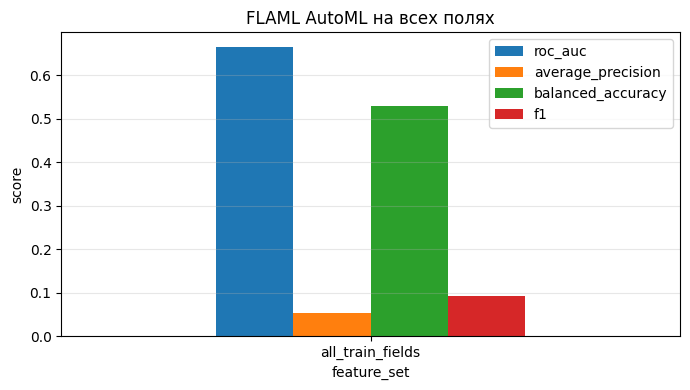

In [10]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

final_results_df.set_index("feature_set")[metrics_to_plot].plot(
    kind="bar", figsize=(7, 4), rot=0, title="FLAML AutoML на всех полях"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
best_feature_set = final_results_df.loc[0, "feature_set"]
best_model_path = Path(final_results_df.loc[0, "model_path"])

print("best feature set:", best_feature_set)
print("best model:", best_model_path)
print("best val roc auc:", final_results_df.loc[0, "roc_auc"])
print("best threshold:", final_results_df.loc[0, "threshold"])
print("best estimator:", final_results_df.loc[0, "best_estimator"])

best feature set: all_train_fields
best model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_full_fields_models/flaml_all_train_fields_0.66582.pkl
best val roc auc: 0.6658168123948146
best threshold: 0.059987667888961926
best estimator: lgbm


## Confusion matrix для модели на всех полях

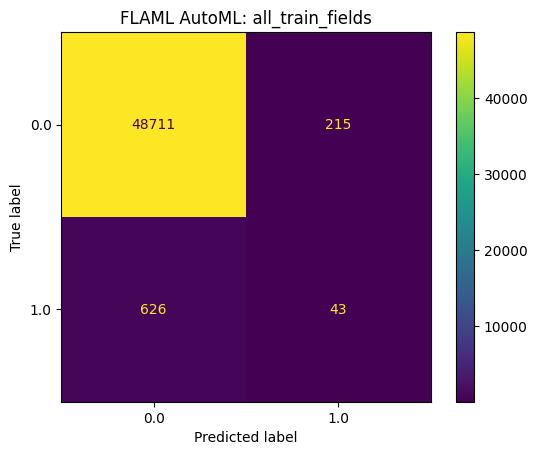

roc auc: 0.6658168123948146
average precision: 0.05454211244402441
balanced accuracy: 0.5299403229195709
f1: 0.09277238403451996


In [12]:
with open(best_model_path, "rb") as f:
    best_model = pickle.load(f)

y_score_best = positive_class_score(best_model, X_val)
y_pred_best = predict_with_threshold(
    y_score_best, final_thresholds.get(best_feature_set, final_results_df.loc[0, "threshold"])
)

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best)
plt.title(f"FLAML AutoML: {best_feature_set}")
plt.show()

count_metrics(y_val, y_pred_best, y_score_best)

## Предсказание для test и сабмит

Подсасываем шаблон

In [13]:
RUN_SUBMISSION = True

if RUN_SUBMISSION:
    with open(best_model_path, "rb") as f:
        best_model = pickle.load(f)

    test_score = positive_class_score(best_model, X_test)

    submit_candidates = [
        DATA_DIR / "sample_submission.csv",
        DATA_DIR / "submit.csv",
        PROJECT_DIR / "sample_submission.csv",
        PROJECT_DIR / "submit.csv",
        PROJECT_DIR / "raw_data" / "sample_submission.csv",
        PROJECT_DIR / "raw_data" / "submit.csv",
    ]
    submit_path = next((path for path in submit_candidates if path.exists()), None)

    if submit_path is not None:
        submission = pd.read_csv(submit_path)
        target_col = "target" if "target" in submission.columns else submission.columns[-1]
        submission[target_col] = test_score
    else:
        submission = pd.DataFrame(
            {
                "index": X_test.index,
                "target": test_score,
            }
        )

    score_for_name = final_results_df.loc[0, "roc_auc"]
    submission_path = SUBMISSIONS_DIR / f"flaml_{best_feature_set}_{score_for_name:.5f}.csv"
    submission.to_csv(submission_path, index=False)

    print("submission saved:", submission_path)
    display(submission.head())

    del best_model, test_score, submission
    gc.collect()

submission saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions/flaml_all_train_fields_0.66582.csv


,index,score
0,194357,0.002398
1,313222,0.011563
2,321873,0.028287
3,118689,0.009279
4,342561,0.004458


## Сохранение таблиц с результатами

In [14]:
final_results_path = LOGS_DIR / "final_results.csv"
final_results_df.to_csv(final_results_path, index=False)

print("final results saved:", final_results_path)

final results saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/flaml_automl_full_fields_log/final_results.csv
